# GEOG5990M Final Assignment

(The cover sheet has been adapted from the word doc. to support use with .ipynb files - please complete all the requested info.)
###  COURSEWORK COVERSHEET
- Student ID number: 201973991
- Module code: GEOG5990M
- Module title: Programming for Geographical Information Analysis
- Assignment title: Spatial data science report
- Marker: Francesca Pontin
- Declared word count:

#### Use of Generative Artificial Intelligence (Gen AI) in this assessment – delete one statement as appropriate
- I have made no use of Gen AI
- I have used Gen AI only for the specific purposes outlined in my acknowledgements. Yes


By submitting the work in this notebook you confirm your compliance with the University’s definition of Academic Integrity as: “a commitment to good study practices and shared values which ensures that my work is a true expression of my own understanding and ideas, giving credit to others where their work contributes to mine”. Double-check that your referencing and use of quotations is consistent with this commitment.

You also confirm that your declared word count accurately reflects the number of words in your submission, excluding the overall title, Gen AI use acknowledgement, bibliography/reference list, text/numbers in tables and figures (although table and figure captions are included in the word count).

# Research Question

This project investigates the relationship between socio-economic deprivation and house prices in Leeds.

Specifically, it asks:

**Is there an association between Index of Multiple Deprivation (IMD) scores and house prices across LSOAs in Leeds?**

This question is important for understanding spatial inequality and can provide insights for policymakers and urban planners.

# Data

This project uses three datasets:
- House price data (2021)
- Population data (2021)
- Index of Multiple Deprivation (IMD) data (2019)

All datasets are linked using the LSOA code, allowing spatial comparison across Leeds.

The original house price dataset was large and contained data for all UK regions.
To improve efficiency, the dataset was filtered in advance to include only Leeds observations.
The cleaned dataset is used directly in this analysis.

In [156]:
price_df = pd.read_csv("leeds_house_price_2021(1).csv")

price_df.head()

,LSOA_code,house_price
0,E01011264,207500.0
1,E01011265,289950.0
2,E01011266,332500.0
3,E01011267,228000.0
4,E01011268,175000.0


In [157]:
pop_df = pd.read_csv("leeds_population_2021.csv")

pop_df.head()

/tmp/ipykernel_17771/1193157883.py:1: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  pop_df = pd.read_csv("leeds_population_2021.csv")


,area_name,LSOA_code,population
0,Leeds 001A,E01011698,1462.0
1,Leeds 001B,E01011699,1289.0
2,Leeds 001C,E01011701,1367.0
3,Leeds 001D,E01011702,1648.0
4,Leeds 001E,E01011703,1224.0


In [158]:
merged_df = price_df.merge(pop_df, on="LSOA_code")

merged_df.head()

,LSOA_code,house_price,area_name,population
0,E01011264,207500.0,Leeds 011A,1284.0
1,E01011265,289950.0,Leeds 009A,1955.0
2,E01011266,332500.0,Leeds 008A,2613.0
3,E01011267,228000.0,Leeds 009B,1699.0
4,E01011268,175000.0,Leeds 010A,1395.0


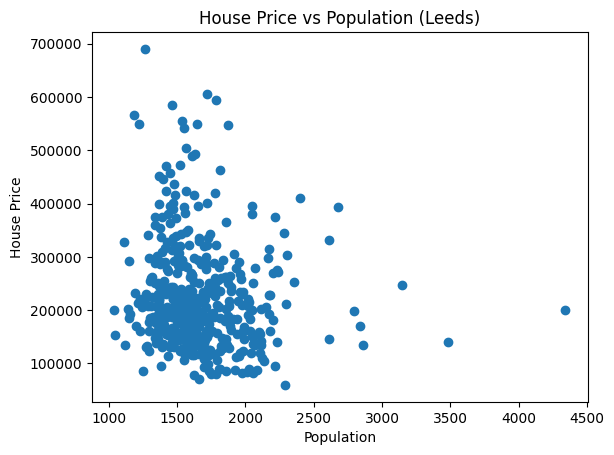

In [159]:
import matplotlib.pyplot as plt

plt.scatter(merged_df["population"], merged_df["house_price"])
plt.xlabel("Population")
plt.ylabel("House Price")
plt.title("House Price vs Population (Leeds)")
plt.show()

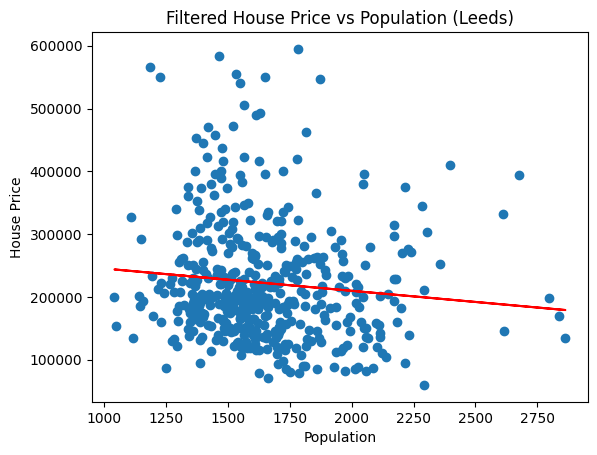

In [160]:
#
import numpy as np
clean_df = merged_df[
    (merged_df["house_price"] < 600000) &
    (merged_df["population"] < 3000)
]

#
x = clean_df["population"]
y = clean_df["house_price"]

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y)
plt.plot(x, m*x + b, color='red')

plt.xlabel("Population")
plt.ylabel("House Price")
plt.title("Filtered House Price vs Population (Leeds)")
plt.show()

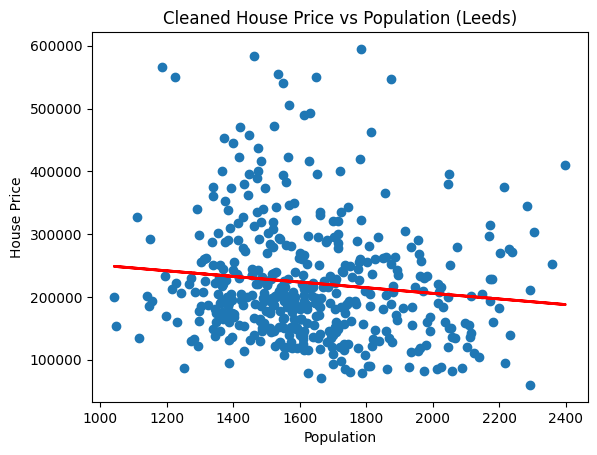

In [161]:
clean_df = merged_df[
    (merged_df["house_price"] < 600000) &
    (merged_df["population"] < 2500)
]
x = clean_df["population"]
y = clean_df["house_price"]

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y)
plt.plot(x, m*x + b, color='red', linewidth=2)

plt.xlabel("Population")
plt.ylabel("House Price")
plt.title("Cleaned House Price vs Population (Leeds)")
plt.show()

# Exploratory Analysis

An initial analysis explored the relationship between population and house prices in Leeds. The scatter plot shows a weak correlation between the two variables, indicating that population alone is not a strong predictor of house prices.

Therefore, the focus of the analysis shifted to socio-economic deprivation (IMD), which is expected to have a stronger relationship with housing values.

IMD scores represent levels of socio-economic deprivation across areas in England [1].

In [162]:
imd_df = pd.read_csv('leeds_imd_2019.csv')

imd_df.head()

/tmp/ipykernel_17771/1319396865.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  imd_df = pd.read_csv('leeds_imd_2019.csv')


,LSOA_code,IMD_Score
0,E01011264,20.525
1,E01011265,13.602
2,E01011266,5.808
3,E01011267,27.863
4,E01011268,34.444


In [163]:
imd_df.columns = imd_df.columns.str.strip()  #
imd_df = imd_df.rename(columns={
    'LSOA code (2011)': 'LSOA_code',
    'LSOA code': 'LSOA_code',
    'IMD Score': 'IMD_score',
    'Index of Multiple Deprivation (IMD) Score': 'IMD_score'
})
merged_df = price_df.merge(pop_df, on='LSOA_code')
merged_df = merged_df.merge(imd_df, on='LSOA_code')

merged_df.head()

,LSOA_code,house_price,area_name,population,IMD_Score
0,E01011264,207500.0,Leeds 011A,1284.0,20.525
1,E01011265,289950.0,Leeds 009A,1955.0,13.602
2,E01011266,332500.0,Leeds 008A,2613.0,5.808
3,E01011267,228000.0,Leeds 009B,1699.0,27.863
4,E01011268,175000.0,Leeds 010A,1395.0,34.444


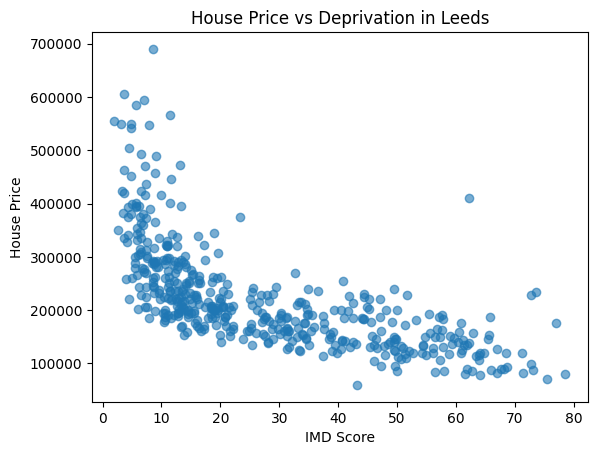

In [164]:
import matplotlib.pyplot as plt
import numpy as np

x = merged_df["IMD_Score"]
y = merged_df["house_price"]

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y, alpha=0.6)
plt.plot(x, m*x + b, color="red", linewidth=2)

plt.xlabel("IMD Score")
plt.ylabel("House Price")
plt.title("House Price vs Deprivation in Leeds")
plt.show()

In [165]:
corr = merged_df["IMD_Score"].corr(merged_df["house_price"])
print("Correlation:", corr)

Correlation: -0.6638117682027144


# Relationship between IMD and House Price

The scatter plot shows a clear negative relationship between IMD score and house prices in Leeds.

Areas with higher deprivation (higher IMD scores) tend to have lower house prices. This is supported by the correlation coefficient (r ≈ -0.60), indicating a moderately strong negative relationship.

This suggests that socio-economic conditions play an important role in determining property values.

The spatial boundary data (Leeds.geojson) was provided as part of the GEOG5990M course materials [2].

In [166]:
import geopandas as gpd

map_df = gpd.read_file("Leeds.geojson")
map_df.head()

,FID,LSOA21CD,LSOA21NM,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,10720,E01011264,Leeds 011A,420937,441836,-1.68306,53.87232,14a73329-fc8f-464c-a4fa-1963baa35500,"POLYGON ((421248.688 442315.812, 421284.072 44..."
1,10721,E01011265,Leeds 009A,418988,441951,-1.71269,53.87343,eda471dd-f408-4dab-917e-c5e188310b35,"POLYGON ((418635 442559, 418637.555 442552.869..."
2,10722,E01011266,Leeds 008A,417489,442615,-1.73545,53.87945,286c32c5-ef49-4ecc-a45e-57630c165c62,"POLYGON ((417783.688 443382.312, 417788.688 44..."
3,10723,E01011267,Leeds 009B,419641,442025,-1.70276,53.87407,318cfaa3-9f08-4d61-a30e-82e903f3a7ba,"POLYGON ((419607.843 442388.568, 419612.752 44..."
4,10724,E01011268,Leeds 010A,420224,441935,-1.69390,53.87324,049e79f0-cd9e-47dc-848b-b6d6fa6825ac,"POLYGON ((420442.406 442436.687, 420443.313 44..."


In [167]:
map_merged = map_df.merge(
    merged_df,
    left_on="LSOA21CD",
    right_on="LSOA_code"
)

map_merged.head()

,FID,LSOA21CD,LSOA21NM,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,LSOA_code,house_price,area_name,population,IMD_Score
0,10720,E01011264,Leeds 011A,420937,441836,-1.68306,53.87232,14a73329-fc8f-464c-a4fa-1963baa35500,"POLYGON ((421248.688 442315.812, 421284.072 44...",E01011264,207500.0,Leeds 011A,1284.0,20.525
1,10721,E01011265,Leeds 009A,418988,441951,-1.71269,53.87343,eda471dd-f408-4dab-917e-c5e188310b35,"POLYGON ((418635 442559, 418637.555 442552.869...",E01011265,289950.0,Leeds 009A,1955.0,13.602
2,10722,E01011266,Leeds 008A,417489,442615,-1.73545,53.87945,286c32c5-ef49-4ecc-a45e-57630c165c62,"POLYGON ((417783.688 443382.312, 417788.688 44...",E01011266,332500.0,Leeds 008A,2613.0,5.808
3,10723,E01011267,Leeds 009B,419641,442025,-1.70276,53.87407,318cfaa3-9f08-4d61-a30e-82e903f3a7ba,"POLYGON ((419607.843 442388.568, 419612.752 44...",E01011267,228000.0,Leeds 009B,1699.0,27.863
4,10724,E01011268,Leeds 010A,420224,441935,-1.69390,53.87324,049e79f0-cd9e-47dc-848b-b6d6fa6825ac,"POLYGON ((420442.406 442436.687, 420443.313 44...",E01011268,175000.0,Leeds 010A,1395.0,34.444


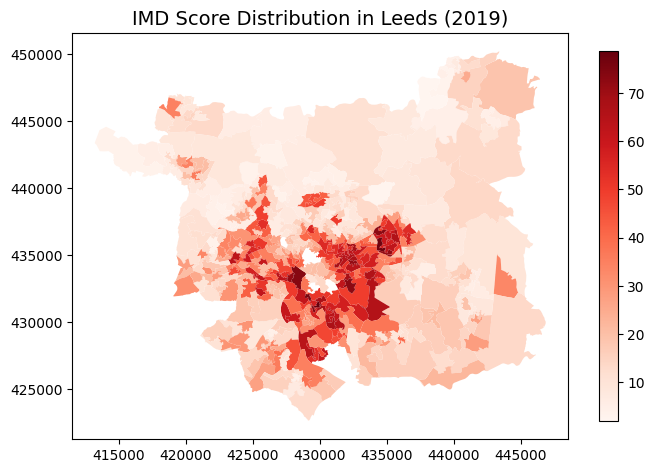

In [168]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

map_merged.plot(
    column="IMD_Score",
    legend=True,
    cmap="Reds",
    ax=ax,
    legend_kwds={'shrink': 0.6}
)

ax.set_title("IMD Score Distribution in Leeds (2019)", fontsize=14)

plt.show()

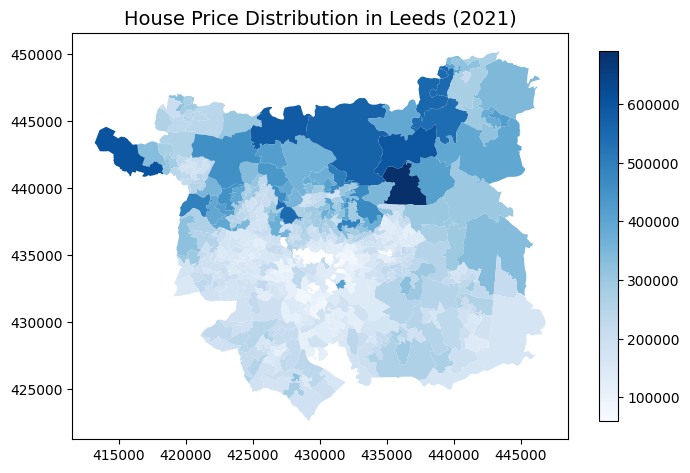

In [169]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

map_merged.plot(
    column="house_price",
    legend=True,
    cmap="Blues",
    ax=ax,
    legend_kwds={'shrink': 0.6}
)

ax.set_title("House Price Distribution in Leeds (2021)", fontsize=14)

plt.show()

### Spatial Patterns

The spatial distribution shows clear geographic differences across Leeds.

Higher deprivation levels are concentrated in central areas, while higher house prices are found in less deprived outer areas.

This spatial pattern supports the negative relationship observed in the scatter plot and highlights socio-economic inequality.

### Conclusion

This study investigated the relationship between socio-economic deprivation and house prices in Leeds. The results show a clear negative association between IMD scores and house prices, with more deprived areas generally having lower property values.

Initial exploratory analysis indicated that population had only a weak relationship with house prices, suggesting it is not a strong explanatory factor. In contrast, deprivation was found to have a more meaningful and consistent influence, supported by both statistical analysis and spatial visualisation.

The spatial patterns further highlight inequalities within Leeds, with higher deprivation concentrated in central areas and higher house prices located in less deprived outer areas. Together, these findings demonstrate the importance of socio-economic conditions in shaping the housing market.

However, this analysis has some limitations. The datasets are from different years (IMD 2019 and house price/population 2021), which may affect the accuracy of the results. In addition, other potentially important variables, such as income levels and housing characteristics, were not included.

The findings may be useful for policymakers and local authorities in identifying areas that require targeted investment and regeneration. Addressing socio-economic inequality could contribute to a more balanced and equitable housing market in Leeds.

Data Visualisation
- Don't forget to present your final two data visualisation (one spatial and one non-spatial) and the justifications about the decisions you made whilst preparing and visualising the data.

## References

[1] UK Government (2019) *English Indices of Deprivation 2019*.  
https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019

[2] GEOG5990M course materials

